In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 4** - Optimal Product Placement

- Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly.

- To speed up decision-making, an ML model approximates these results within hours.
  - The model has **four hyperparameters** to tune, and its output reflects the _difference from the expensive baseline_.
    - Because the system is _dynamic_ and _full of local optima_.
    - It requires **careful tuning** and **robust validation** to find reliable, near-optimal solutions.

- **Inputs** = 4D array (30, 4)

- **Outputs** = 1D array (30, )

- **Goal** - Maximization


- We only have 30 data points to start with, the space between our points is quite large.
  - This means that our Gaussian Process model will have high uncertainty in many regions of the input space.


In [4]:
X = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_4\initial_inputs.npy')
Y = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_4\initial_outputs.npy')

### **Random Search**

- This is the fist simple method to get a query just to explore thorugh trial-and-error method to just get a guage of the space.


In [5]:
next_query = np.random.uniform(size = 4)
print(next_query)

[0.03347899 0.31170092 0.33720192 0.3519929 ]


### **Bayesian Optimisation** - Gaussian Process strategic approach

- For this particular problem I am using the Matern kerenl as in comparison the RBF kerel is a bit too smooth whereas in this paricular looking at the use case we need to use a Matern.
  - It allows the model to recognize sharp changes in the warehouse efficiency surface.

- For the noise I am going to go quite low (`1e-3`) as the model is an approximation, meaning the output is probably consistent.


In [6]:
kernel = Matern(length_scale=1.0, nu=1.5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    alpha=1e-3,
    normalize_y=True,
    random_state=42
)

model.fit(X, Y)

GaussianProcessRegressor(alpha=0.001, kernel=Matern(length_scale=1, nu=1.5),
                         n_restarts_optimizer=10, normalize_y=True,
                         random_state=42)

### **Acquisition Function** - Execpted Improvement (EI)

- After some research, EI seems to be an industry standard for 4D+ spaces.
  - I found out that the main reason for this - _It excels at balancing the "**high risk/high reward**" of unexplored areas with the "**safe bet**" of refining near existing good results._


In [10]:
def expected_improvement(X_grid, model, y_max, xi=0.01):
    
    mu, sigma = model.predict(X_grid, return_std=True)
    
    mu = mu.reshape(-1, 1)
    sigma = sigma.reshape(-1, 1)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        improvement = mu - y_max - xi
        Z = improvement / (sigma + 1e-9)
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0
    
    return ei.ravel()

# Calculate the values using the function
y_max = np.max(Y)
x_grid = np.random.uniform(0, 1, (10000, 4))
ei_values = expected_improvement(x_grid, model, y_max, xi=0.01)

# Find the best index from the calculated values
best_idx = np.argmax(ei_values)
next_query = x_grid[best_idx]

print(f"Next Submission for Function 4 - Bayesian Optimisation (EI): "
      f"{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}")

Next Submission for Function 4 - Bayesian Optimisation (EI): 0.484570-0.429553-0.398666-0.369789


It is important to note that the 1e-8 used in the calulation for z is used as without this I was getting `MemeoryError`

- In a 4D model can become "too certain" about a point it has already seen, making the uncertainty ($\sigma$) zero.
- After some research on why this error was occuring I found out that the Computers can't divide by zero. Adding this tiny "jitter" ensures the code remains robust and finishes the calculation without crashing your environment.

I thought that + 1e-9 made the Expected Improvement calculation smooth and continuous.


### **Visualisation of the input to the output**


- The visualisation is a simple tool to see how my inputs ranked per week so that I know the improvements week by week.
  - This also helps me understand the highest and lowest output values visually.

- The other choice I have taken - using 2 decimal places instead of the full 6 as seen in the output.


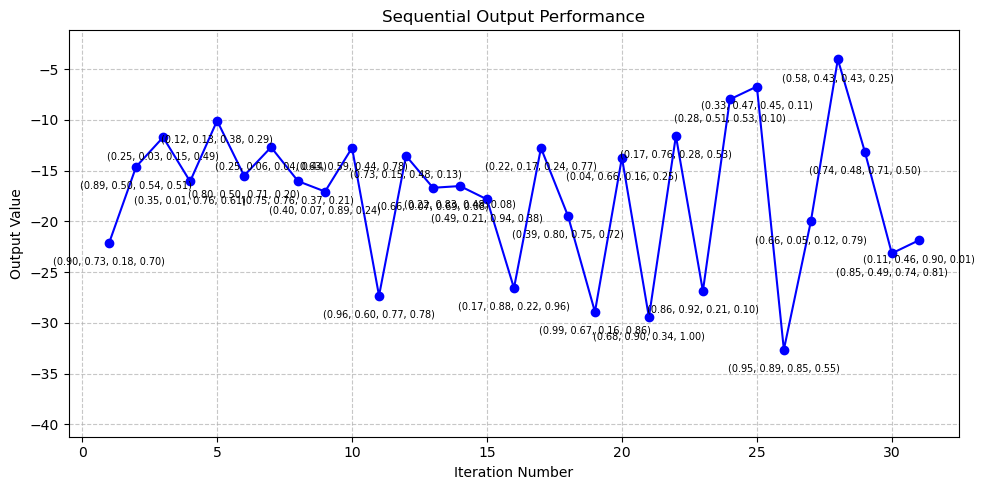

In [8]:
import numpy as np
import matplotlib.pyplot as plt

iterations = np.arange(1, len(Y) + 1)

# Plot the output values in order
plt.figure(figsize=(10, 5))
plt.plot(iterations, Y, marker='o', linestyle='-', color='b')

# Simple titles and axis labels
plt.title('Sequential Output Performance')
plt.xlabel('Iteration Number')
plt.ylabel('Output Value')
plt.grid(True, linestyle='--', alpha=0.7)

# Annotate each point with its corresponding input values
for i in range(len(Y)):
    input_label = f"({X[i,0]:.2f}, {X[i,1]:.2f}, {X[i,2]:.2f}, {X[i,3]:.2f})"
    
    plt.annotate(input_label, 
                 (iterations[i], Y[i]), 
                 textcoords="offset points", 
                 xytext=(0, -10), 
                 va='top',
                 ha='center', 
                 fontsize=7, 
                 linespacing=1.2)

plt.tight_layout()
plt.ylim(min(Y) - (max(Y)-min(Y))*0.3, max(Y) + (max(Y)-min(Y))*0.1)
plt.show()

### **Reasons for having a different input values for week 1 than what is shown here**

**Final Decision** - Due to inability of going through this process in time for week 1 submission I choose the input points which were purely based on exploration.

- **Hence the input for week 1** - [0.11245-0.456812-0.901233-0.005678]

- I will be using this thinking process and methodology moving forward into week 2.
